In [ ]:
print("hello")

import geopandas

hello


In [ ]:
# Décommentez si nécessaire :
#!pip install geopandas matplotlib folium geodatasets


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import geopandas as gpd 
import matplotlib.pyplot as plt

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
monde = gpd.read_file(url)

print("Type:", type(monde))
print("dimensions", monde.shape)
print("colonnes", list(monde.columns))
print("CRS :", monde.crs)

#filtrer l'afrique
afrique = monde[monde["CONTINENT"] == "Africa"]
print(f"nombre de pays: {len(afrique)}")
afrique.head()

Type: <class 'geopandas.geodataframe.GeoDataFrame'>
dimensions (177, 169)
colonnes ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
11,Admin-0 country,1,2,Democratic Republic of the Congo,COD,0,2,Sovereign country,1,Democratic Republic of the Congo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((29.34 -4.49998, 29.51999 -5.41998, 2..."
12,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((41.58513 -1.68325, 40.993 -0.85829, ..."
13,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((39.20222 -4.67677, 37.7669 -3.67712,..."


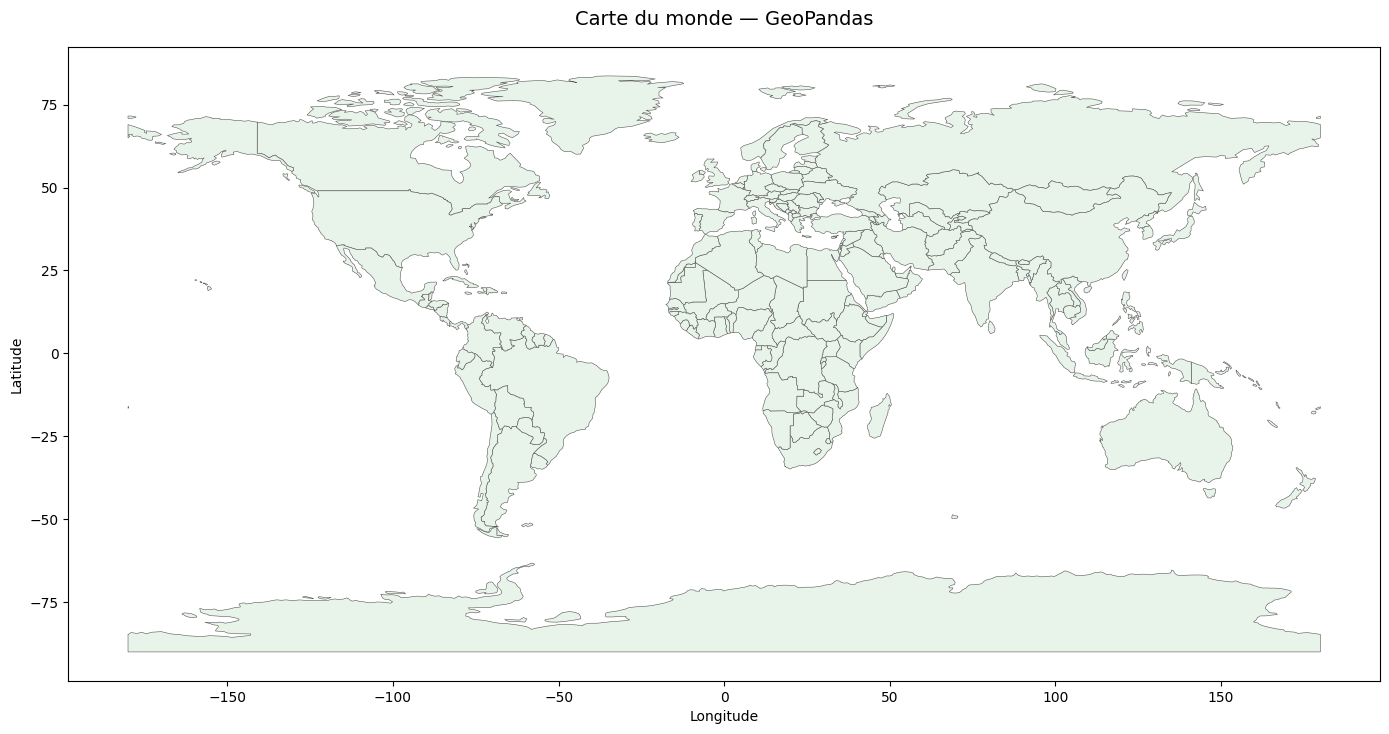

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

monde.plot(
    ax=ax,
    color='#e8f4ea',
    edgecolor='#555453',
    linewidth=0.4
)

ax.set_title("Carte du monde — GeoPandas", fontsize=14, pad=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [15]:
# Simulons des données terrain (relevés GPS)
import pandas as pd
from shapely.geometry import Point

# Données brutes (comme un export GPS)
data = {
    'id':     [1,       2,       3,       4,       5],
    'nom':    ['Site A','Site B','Site C','Site D','Site E'],
    'type':   ['puits', 'école', 'puits', 'route', 'école'],
    'lon':    [1.221,   1.235,   1.198,   1.254,   1.211],
    'lat':    [6.137,   6.152,   6.121,   6.145,   6.163]
}
df = pd.DataFrame(data)

# Convertir en GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"  # WGS84 = le GPS standard
)

print("GeoDataFrame créé !")
gdf_points

GeoDataFrame créé !


,id,nom,type,lon,lat,geometry
0,1,Site A,puits,1.221,6.137,POINT (1.221 6.137)
1,2,Site B,école,1.235,6.152,POINT (1.235 6.152)
2,3,Site C,puits,1.198,6.121,POINT (1.198 6.121)
3,4,Site D,route,1.254,6.145,POINT (1.254 6.145)
4,5,Site E,école,1.211,6.163,POINT (1.211 6.163)


In [17]:
#!pip install mapclassify
gdf_points.explore()